In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:

def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()
def draw_bounding_boxes(image, rectangles, color=(255, 0, 0), thickness=2):
    '''
    returns image and the bounding boxes calculated
    '''
    img_copy = image.copy()
    for x, y, w, h in rectangles:
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), color, thickness)
    print(f"{len(rectangles)} bounding boxes found.")
    return img_copy


In [20]:
def get_list_of_rectangles(image, min_area_contour, max_area_contour, scale, max_ratio, upper_limit_rectangles = None, value_threshold = None, binary_default = True):
    """
    Returns:
        rectangles : list of [x, y, w, h]
    """
    rectangles = []
    value_problems = 0


    #find contours in bw image
    inverted_mask = cv2.bitwise_not(create_binary_mask(image, binary_default))
    contours, _ = cv2.findContours(inverted_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    for contour in contours:
        #get contour area
        contour_area = cv2.contourArea(contour)


        if value_threshold:
            
            # create mask for this contour
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, color=255, thickness=-1)
            
            # mean value for this contour
            mean_value = cv2.mean(hsv[:, :, 2], mask=mask)[0]


            if mean_value < value_threshold:
                value_problems += 1
                continue

        #filter by contour size
        if not (min_area_contour <= contour_area <= max_area_contour):
            continue

        #create and scale rectangles around contour    
        x, y, w, h = cv2.boundingRect(contour)
        x, y, w, h = scale_rect(x, y, w, h, scale)

        #exclude empty rectangles
        if w == 0 or h == 0:
            continue
        
        #filter rectangles by squareness and size
        ratio = max(w, h) / min(w, h)
        if ratio > max_ratio:
            continue
        area = w*h
        if upper_limit_rectangles is not None and area > upper_limit_rectangles:
            continue

        rectangles.append([x, y, w, h])

    return rectangles,value_problems

def scale_rect(x, y, w, h, scale):
    """
    Scales a rectangle around its center.
    """
    # Center of original rectangle
    cx = x + w / 2
    cy = y + h / 2

    # New width and height
    new_w = w * scale
    new_h = h * scale

    # New top-left corner
    new_x = cx - new_w / 2
    new_y = cy - new_h / 2

    return int(new_x), int(new_y), int(new_w), int(new_h)

def remove_smaller_overlaps(rectangles):
    """
    Removes rectangles that overlap with a larger rectangle.
    
    Parameters:
        rectangles (list of [x,y,w,h])
        
    Returns:
        cleaned list of rectangles with overlaps removed (smaller ones deleted)
    """
    rectangles = rectangles.copy()  # avoid modifying the original list
    
    def overlap(r1, r2):
        x1, y1, w1, h1 = r1
        x2, y2, w2, h2 = r2
        x1_max, y1_max = x1 + w1, y1 + h1
        x2_max, y2_max = x2 + w2, y2 + h2
        if x1_max <= x2 or x2_max <= x1:
            return False
        if y1_max <= y2 or y2_max <= y1:
            return False
        return True
    
    i = 0
    while i < len(rectangles):
        j = i + 1
        while j < len(rectangles):
            if overlap(rectangles[i], rectangles[j]):
                area_i = rectangles[i][2] * rectangles[i][3]
                area_j = rectangles[j][2] * rectangles[j][3]
                # Remove the smaller rectangle
                if area_i >= area_j:
                    del rectangles[j]
                else:
                    del rectangles[i]
                    i -= 1  # need to recheck new rectangle at i
                    break  # restart inner loop
            else:
                j += 1
        i += 1
    
    return rectangles



# combined
def create_binary_mask(image, binary_default = True):
    '''
    binary masking with manual set threshold (yellow)
    '''
    if binary_default:
        print("using only simple binarization.")   
        lower_yellow = np.array([20, 100, 100])
        upper_yellow = np.array([30, 255, 255])
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
        return mask
    
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    s = clahe.apply(s)

    # Adaptive S channel thresholds for yellow
    lower_s = max(50, int(np.percentile(s, 1)))
    lower_yellow = np.array([20, lower_s, 100])
    upper_yellow = np.array([30, 255, 255])
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

    # Morphological cleanup #increases processing time
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask



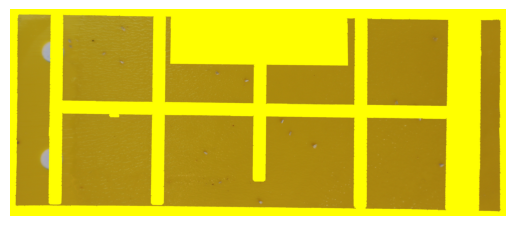

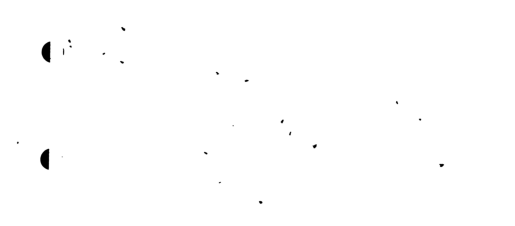

In [21]:
#1 normal
#img = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/03_images_masked/BRAIIM_0003.jpg")
#image_file = "BRAIIM_0003.jpg"
img = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked/TRIAVA_0007.jpg")
image_file = "TRIAVA_0007.jpg"

show(img)
show(create_binary_mask(img, binary_default = False))

In [33]:
if "TRIAVA" in image_file:
    min_area_contour = 100 
    max_area_contour = 2000
    scale = 1.5
    max_ratio = 2 
    upper_limit_rectangles = None
    value_threshold =97 # 5th percentile
    binary_default = False
elif "LIRIBO" in image_file: 
    min_area_contour = 1000 
    max_area_contour = 10000 
    scale = 1.5
    max_ratio = 1.76 #95th percentile
    upper_limit_rectangles = 28530 #22340 #95th percentile
    value_threshold = None
elif "BRAIIM" in image_file:
    min_area_contour = 2000 
    max_area_contour = 10000
    scale = 1.5
    max_ratio = 1.73 #1.75 #95the percentile
    upper_limit_rectangles = 42970 #41703 #95th percentil
    value_threshold = None
rectangles, v = get_list_of_rectangles(img, min_area_contour, max_area_contour, scale, max_ratio, upper_limit_rectangles, value_threshold, binary_default)
if "TRIAVA" in image_file:
    count = len(rectangles)
    rectangles = remove_smaller_overlaps(rectangles)

17 bounding boxes found.


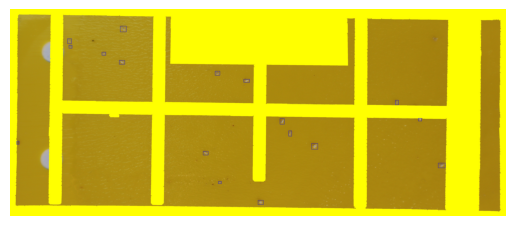

In [34]:
show(draw_bounding_boxes(img, rectangles))

In [48]:
inverted_mask = cv2.bitwise_not(create_binary_mask(img, binary_default = False), )
contours, _ = cv2.findContours(inverted_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)


22

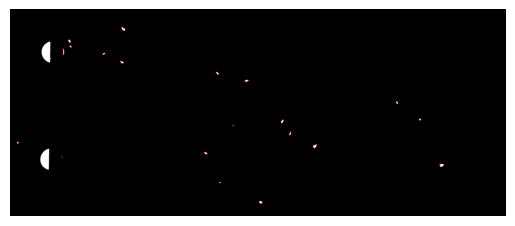

True

In [51]:
img_labeled = img.copy()
img_labeled = cv2.cvtColor(inverted_mask, cv2.COLOR_GRAY2BGR)

for i, c in enumerate(contours):
    if cv2.contourArea(c) > 100 and cv2.contourArea(c) < 2000:
        # Draw contour
        cv2.drawContours(img_labeled, [c], -1, (0,0,255), 2)

        # Compute contour center (centroid)
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0

        # Label with contour index
        #cv2.putText(img_labeled, str(i), (cx, cy),
        #            cv2.FONT_HERSHEY_SIMPLEX, 5, (255,255,255), 2)
show(img_labeled)
cv2.imwrite("contours.jpg", img_labeled)


In [ ]:
for c in contours:
    a = cv2.contourArea
    print(cv2.contourArea(c))

1258.5
567.0
1871.0
963.0
955.0
21224.5
1873.5
325.5
870.5
1099.0
616.0
1264.5
963.0
1317.0
1253.0
1152.0
1852.0
1030.0
21421.0
414.5
1579.0
930.0
304.5
87.0
2557.5
119.0
97.0
217.5
87.0
141.0
505.0
98.0
236.0
1233.0
10209.5


In [31]:
labels_folder ="/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/04_labels_cropped"
label_file = os.path.splitext(image_file)[0] + ".txt"
label_path = os.path.join(labels_folder, label_file)
with open(label_path, "r") as f:
    yolo_rectangles = [
        tuple(map(int, line.strip("()\n ").split(",")))
        for line in f
    ]


    


#rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in rectangles]
#yolo_rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in yolo_rectangles]
#stats, fp_boxes = evaluate_detections(rectangles, yolo_rectangles)

28 bounding boxes found.


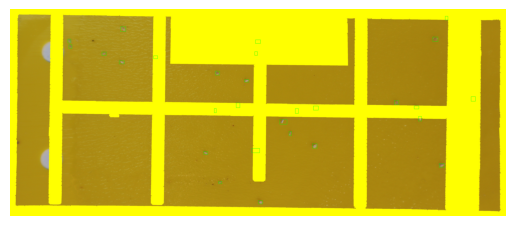

True

In [52]:
#image_labels = draw_bounding_boxes(img, rectangles)
image_labels = draw_bounding_boxes(img, yolo_rectangles, color = (0,255,0))
show(image_labels)
cv2.imwrite("ground_truth.jpg", image_labels)

In [1]:
import os
label_paths = ["/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv1",
               "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv1_pure",
               "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv2",
               "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv2_pure",
               "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/labels",
               ]

In [2]:
for path in label_paths:
    files = os.listdir(path)
    sum = [0,0,0]
    print(path)
    for file in files:
        with open(os.path.join(path, file), "r") as f:
            lines = f.readlines()
        if file.startswith("BRAIIM"):
            sum[0] += len(lines)
        if file.startswith("LIRIBO"):
            sum[1] += len(lines)
        if file.startswith("TRIAVA"):
            sum[2] += len(lines)
    print(sum)

    

/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv1
[2693, 2720, 4786]
/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv1_pure
[2693, 2720, 4885]
/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv2
[2693, 2720, 4554]
/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_unlabeled/05_created_labelsv2_pure
[2693, 2720, 4632]
/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/labels
[5343, 5298, 8952]


In [6]:
path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/manual_SSL/images"
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/labels"
files = os.listdir(path)
sum = [0,0,0]
print(path)
for file in files:
    label_file = os.path.splitext(file)[0] + ".txt"
    with open(os.path.join(label_path, label_file), "r") as f:
        lines = f.readlines()
    if file.startswith("BRAIIM"):
        sum[0] += len(lines)
    if file.startswith("LIRIBO"):
        sum[1] += len(lines)
    if file.startswith("TRIAVA"):
        sum[2] += len(lines)
print(sum)


/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/manual_SSL/images
[1835, 1737, 4896]
